# ML Pipeline for 5Ghz Device Prediction Positioning Model

This notebook contains the machine learning pipeline used to train a device positioning model from the labelled dataset in `ml_dataset.parquet`.

<br>

---

<br>

## Regression Problem

The machine learning task is formulated as a supervised multi-output regression problem:

$$
f(\mathbf{x}_i) \to \mathbf{y}_i =
\begin{bmatrix}
x_i \\
y_i
\end{bmatrix}
$$

where:

- $\mathbf{x}_i$ is the input feature vector for the $i$-th sample
- $\mathbf{y}_i$ is the ground-truth 2D target position
- $f(\cdot)$ is the learned regression function

Equivalently, the model learns:

$$
\hat{\mathbf{y}}_i = f(\mathbf{x}_i)
$$

with prediction error measured by the Euclidean localisation error:

$$
e_i = \sqrt{(\hat{x}_i - x_i)^2 + (\hat{y}_i - y_i)^2}
$$

The training objective is to learn a function $f$ that minimises prediction error over all training samples.

This notebook follows four core principles:
1. Use one row per `scenario_id` + `target_id`.
2. Split by unseen `scenario_id` groups rather than by random rows.
3. Compare simple baselines before more complex fusion models.
4. Drop leakage columns that would not exist at inference time.

<br>

---

<br>

## Data Split Strategy

To evaluate generalisation to unseen environments, the dataset **(100 network environments)** is split by unique `scenario_id` groups. This prevents the model from seeing the same environment in both training and evaluation, which would otherwise inflate performance.

The grouped split used in this notebook is:

- **Training set (70%)**  = 70 environments
- **Validation set (20%)**  = 20 environments
- **Testing set (10%)**  = 10 environments

<br>

#### Note:
> Because the split is group-based, the exact environment counts must be rounded to whole numbers.
> One important constraint is that no `scenario_id` appears in more than one split.


In [1]:
%pip install -q pandas pyarrow scikit-learn matplotlib seaborn

In [2]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 13  # Keeping it the same as the environment seed for reproducibility

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def localisation_error_m(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.sum((y_true - y_pred) ** 2, axis=1))


def metric_row(split_name, model_name, y_true, y_pred):
    errors = localisation_error_m(y_true, y_pred)
    return {
        "split": split_name,
        "model": model_name,
        "sample_count": int(len(errors)),
        "mean_error_m": float(errors.mean()),
        "median_error_m": float(np.median(errors)),
        "rmse_m": float(np.sqrt(np.mean(errors ** 2))),
        "p90_error_m": float(np.quantile(errors, 0.90)),
    }


def describe_split(name, frame):
    print(
        f"{name}: rows={len(frame):,}, scenarios={frame['scenario_id'].nunique()}"
    )


## 1. Load `ml_dataset.parquet`

In [6]:
# Set DATA_PATH to local parquet file we want to train on.
DATA_PATH = Path("/ML Pipeline/ml_dataset.parquet").resolve()

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Update DATA_PATH so it points to a local ml_dataset.parquet file."
    )

DATA_DIR = DATA_PATH.parent
dataset_df = pd.read_parquet(DATA_PATH).copy()

print(f"Loaded: {DATA_PATH}")
print(f"Rows: {len(dataset_df):,}")
print(f"Unique scenarios: {dataset_df['scenario_id'].nunique()}")
display(dataset_df.head())


Loaded: /ML Pipeline/ml_dataset.parquet
Rows: 654,871
Unique scenarios: 100


,scenario_id,target_id,target_label,target_x,target_y,target_cell_id,target_row_idx,target_col_idx,target_space_type,target_room_id,target_room_type,target_patio_id,rssi_est_x,rssi_est_y,rssi_error_m,rssi_residual_rmse_m,rssi_anchor_count,rssi_success,tdoa_est_x,tdoa_est_y,tdoa_error_m,tdoa_residual_rmse_m,tdoa_anchor_count,tdoa_success,doa_est_x,doa_est_y,doa_error_m,doa_residual_rmse_m,doa_anchor_count,doa_success,seed,area,env_type,width,height,x_domain_min,x_domain_max,y_range_min,y_range_max,antenna_count,human_count,floor_plan_room_count,floor_plan_patio_count,floor_plan_element_count,target_count,grid_cell_count,valid_grid_cell_count,target_grid_rows,target_grid_cols,target_requested_max_cell_size,target_cell_width,target_cell_height,link_count,antenna_layout_count,antenna_x_mean,antenna_y_mean,antenna_x_min,antenna_x_max,antenna_y_min,antenna_y_max,antenna_coverage_radius_mean_m,antenna_coverage_radius_min_m,antenna_coverage_radius_max_m,antenna_x_std,antenna_y_std,link_anchor_count,link_distance_mean_m,link_distance_min_m,link_distance_max_m,link_wall_blocker_mean,link_wall_blocker_max,link_human_blocker_mean,link_human_blocker_max,link_total_blocker_mean,link_total_blocker_max,link_distance_std_m,link_los_count,link_nlos_count,rssi_measurement_count,rssi_signal_mean_dbm,rssi_signal_min_dbm,rssi_signal_max_dbm,rssi_path_loss_mean_db,rssi_path_loss_min_db,rssi_path_loss_max_db,rssi_path_loss_exponent_mean,rssi_shadow_sigma_mean_db,rssi_obstacle_attenuation_mean_db,rssi_obstacle_attenuation_max_db,rssi_wall_attenuation_mean_db,rssi_human_attenuation_mean_db,rssi_signal_std_dbm,rssi_path_loss_std_db,tdoa_measurement_count,tdoa_observed_mean_ns,tdoa_observed_min_ns,tdoa_observed_max_ns,tdoa_delta_distance_mean_m,tdoa_delta_distance_min_m,tdoa_delta_distance_max_m,tdoa_reference_distance_mean_m,tdoa_comparison_distance_mean_m,tdoa_noise_sigma_mean_ns,tdoa_observed_std_ns,tdoa_delta_distance_std_m,doa_measurement_count,doa_observed_bearing_sin_mean,doa_observed_bearing_cos_mean,doa_observed_doa_sin_mean,doa_observed_doa_cos_mean,doa_noise_sigma_mean_deg
0,scenario_0001,0,target_00000,-175.234457,-303.093029,cell_r0000_c0000,0,0,exterior,None,None,None,-120.423672,-435.038357,142.876841,150.788999,15,True,-175.462481,-303.383600,0.369360,0.051792,15,True,-132.661022,-266.170134,56.354215,41.095156,15,True,13,217207.528271,indoor,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,8774,8856,8774,123,72,5.0,4.936182,4.968738,131610,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803,15,372.363681,81.608800,621.351565,15.066667,31,0.0,0,15.066667,31,157.508860,0,15,15,-122.486043,-132.790307,-94.238930,75.231006,46.983893,85.535270,2.907207,6.143799,0.0,0.0,0.0,0.0,9.582770,9.582770,14,1038.975804,343.519124,1800.349473,311.523087,103.174105,539.742765,81.608800,393.131887,0.148189,468.824051,140.534616,15,-0.763459,-0.462595,-0.763459,-0.462595,9.293095
1,scenario_0001,1,target_00001,-170.298275,-303.093029,cell_r0000_c0001,0,1,exterior,None,None,None,-106.529014,-483.718659,191.551917,254.874879,15,True,-170.138058,-302.991152,0.189864,0.055790,15,True,-109.791294,-241.481018,86.354702,73.557079,15,True,13,217207.528271,indoor,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,8774,8856,8774,123,72,5.0,4.936182,4.968738,131610,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803,15,369.817988,78.255649,619.033595,14.933333,31,0.0,0,14.933333,31,158.132605,0,15,15,-122.495284,-134.655802,-99.268821,75.240247,52.013784,87.400765,2.907207,6.143799,0.0,0.0,0.0,0.0,10.619720,10.619720,14,1042.163876,339.795480,1803.966870,312.388220,101.852955,540.777946,78.255649,390.643869,0.203226,470.824975,141.149743,15,-0.785318,-0.411440,-0.785318,-0.411440,11.130066
2,scenario_0001,2,target_00002,-165.362093,-303.093029,cel

In [7]:
baseline_error_cols = [
    column for column in ["rssi_error_m", "tdoa_error_m", "doa_error_m"]
    if column in dataset_df.columns
]

if baseline_error_cols:
    baseline_summary_df = (
        dataset_df[baseline_error_cols]
        .describe()
        .T[["mean", "50%", "max"]]
        .rename(columns={"50%": "median"})
    )
    display(baseline_summary_df)

scenario_count = dataset_df["scenario_id"].nunique()
if scenario_count < 10:
    warnings.warn(
        "This dataset has fewer than 10 scenarios. The notebook will run, but should probably use the full 100-scenario dataset for the real experiment.",
        stacklevel=2,
    )


,mean,median,max
rssi_error_m,94.054504,79.248349,19624.775619
tdoa_error_m,0.094297,0.071257,2.267963
doa_error_m,22.599255,17.796380,200003.383819


## 2. Keep only inference-safe features

The model should not see any column that directly encodes the target, uses ground-truth geometry, or depends on hidden simulator parameters.


In [8]:
IDENTIFIER_COLUMNS = ["scenario_id", "target_id"]
TARGET_COLUMNS = ["target_x", "target_y"]

ESTIMATE_FEATURE_COLUMNS = [
    "rssi_est_x",
    "rssi_est_y",
    "rssi_residual_rmse_m",
    "rssi_anchor_count",
    "rssi_success",
    "tdoa_est_x",
    "tdoa_est_y",
    "tdoa_residual_rmse_m",
    "tdoa_anchor_count",
    "tdoa_success",
    "doa_est_x",
    "doa_est_y",
    "doa_residual_rmse_m",
    "doa_anchor_count",
    "doa_success",
]

MEASUREMENT_FEATURE_COLUMNS = [
    "rssi_measurement_count",
    "rssi_signal_mean_dbm",
    "rssi_signal_min_dbm",
    "rssi_signal_max_dbm",
    "rssi_signal_std_dbm",
    "tdoa_measurement_count",
    "tdoa_observed_mean_ns",
    "tdoa_observed_min_ns",
    "tdoa_observed_max_ns",
    "tdoa_observed_std_ns",
    "doa_measurement_count",
    "doa_observed_bearing_sin_mean",
    "doa_observed_bearing_cos_mean",
    "doa_observed_doa_sin_mean",
    "doa_observed_doa_cos_mean",
]

METADATA_FEATURE_COLUMNS = [
    "env_type",
    "area",
    "width",
    "height",
    "x_domain_min",
    "x_domain_max",
    "y_range_min",
    "y_range_max",
    "antenna_count",
    "human_count",
    "floor_plan_room_count",
    "floor_plan_patio_count",
    "floor_plan_element_count",
    "antenna_layout_count",
    "antenna_x_mean",
    "antenna_y_mean",
    "antenna_x_min",
    "antenna_x_max",
    "antenna_y_min",
    "antenna_y_max",
    "antenna_coverage_radius_mean_m",
    "antenna_coverage_radius_min_m",
    "antenna_coverage_radius_max_m",
    "antenna_x_std",
    "antenna_y_std",
]

ALLOWED_FEATURE_COLUMNS = [
    *ESTIMATE_FEATURE_COLUMNS,
    *MEASUREMENT_FEATURE_COLUMNS,
    *METADATA_FEATURE_COLUMNS,
]

available_feature_columns = [
    column for column in ALLOWED_FEATURE_COLUMNS if column in dataset_df.columns
]
missing_feature_columns = [
    column for column in ALLOWED_FEATURE_COLUMNS if column not in dataset_df.columns
]

blocked_feature_rules = [
    lambda column: column in TARGET_COLUMNS,
    lambda column: column in {"target_id", "target_label", "scenario_id", "seed"},
    lambda column: column.endswith("_error_m"),
    lambda column: column.startswith("link_"),
    lambda column: "distance" in column,
    lambda column: "attenuation" in column,
    lambda column: "noise_sigma" in column,
    lambda column: "path_loss" in column,
]

excluded_columns = sorted(
    column for column in dataset_df.columns
    if any(rule(column) for rule in blocked_feature_rules)
)

model_df = dataset_df[IDENTIFIER_COLUMNS + TARGET_COLUMNS + available_feature_columns].copy()

for success_column in ["rssi_success", "tdoa_success", "doa_success"]:
    if success_column in model_df.columns:
        model_df[success_column] = model_df[success_column].astype(float)

assert "scenario_id" not in available_feature_columns
assert "target_x" not in available_feature_columns
assert "target_y" not in available_feature_columns
assert not any(column.endswith("_error_m") for column in available_feature_columns)
assert not any("distance" in column for column in available_feature_columns)
assert not any("noise_sigma" in column for column in available_feature_columns)

print(f"Features kept: {len(available_feature_columns)}")
print(f"Columns intentionally excluded: {len(dataset_df.columns) - len(IDENTIFIER_COLUMNS) - len(TARGET_COLUMNS) - len(available_feature_columns)}")
print("\nKept feature columns:")
print(available_feature_columns)
print("\nExamples of excluded leakage or simulator-only columns:")
print(excluded_columns[:30])

if missing_feature_columns:
    print("\nAllowed-but-missing columns for this dataset version:")
    print(missing_feature_columns)

display(model_df.head())


Features kept: 55
Columns intentionally excluded: 52

Kept feature columns:
['rssi_est_x', 'rssi_est_y', 'rssi_residual_rmse_m', 'rssi_anchor_count', 'rssi_success', 'tdoa_est_x', 'tdoa_est_y', 'tdoa_residual_rmse_m', 'tdoa_anchor_count', 'tdoa_success', 'doa_est_x', 'doa_est_y', 'doa_residual_rmse_m', 'doa_anchor_count', 'doa_success', 'rssi_measurement_count', 'rssi_signal_mean_dbm', 'rssi_signal_min_dbm', 'rssi_signal_max_dbm', 'rssi_signal_std_dbm', 'tdoa_measurement_count', 'tdoa_observed_mean_ns', 'tdoa_observed_min_ns', 'tdoa_observed_max_ns', 'tdoa_observed_std_ns', 'doa_measurement_count', 'doa_observed_bearing_sin_mean', 'doa_observed_bearing_cos_mean', 'doa_observed_doa_sin_mean', 'doa_observed_doa_cos_mean', 'env_type', 'area', 'width', 'height', 'x_domain_min', 'x_domain_max', 'y_range_min', 'y_range_max', 'antenna_count', 'human_count', 'floor_plan_room_count', 'floor_plan_patio_count', 'floor_plan_element_count', 'antenna_layout_count', 'antenna_x_mean', 'antenna_y_mean'

,scenario_id,target_id,target_x,target_y,rssi_est_x,rssi_est_y,rssi_residual_rmse_m,rssi_anchor_count,rssi_success,tdoa_est_x,tdoa_est_y,tdoa_residual_rmse_m,tdoa_anchor_count,tdoa_success,doa_est_x,doa_est_y,doa_residual_rmse_m,doa_anchor_count,doa_success,rssi_measurement_count,rssi_signal_mean_dbm,rssi_signal_min_dbm,rssi_signal_max_dbm,rssi_signal_std_dbm,tdoa_measurement_count,tdoa_observed_mean_ns,tdoa_observed_min_ns,tdoa_observed_max_ns,tdoa_observed_std_ns,doa_measurement_count,doa_observed_bearing_sin_mean,doa_observed_bearing_cos_mean,doa_observed_doa_sin_mean,doa_observed_doa_cos_mean,env_type,area,width,height,x_domain_min,x_domain_max,y_range_min,y_range_max,antenna_count,human_count,floor_plan_room_count,floor_plan_patio_count,floor_plan_element_count,antenna_layout_count,antenna_x_mean,antenna_y_mean,antenna_x_min,antenna_x_max,antenna_y_min,antenna_y_max,antenna_coverage_radius_mean_m,antenna_coverage_radius_min_m,antenna_coverage_radius_max_m,antenna_x_std,antenna_y_std
0,scenario_0001,0,-175.234457,-303.093029,-120.423672,-435.038357,150.788999,15,1.0,-175.462481,-303.383600,0.051792,15,1.0,-132.661022,-266.170134,41.095156,15,1.0,15,-122.486043,-132.790307,-94.238930,9.582770,14,1038.975804,343.519124,1800.349473,468.824051,15,-0.763459,-0.462595,-0.763459,-0.462595,indoor,217207.528271,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803
1,scenario_0001,1,-170.298275,-303.093029,-106.529014,-483.718659,254.874879,15,1.0,-170.138058,-302.991152,0.055790,15,1.0,-109.791294,-241.481018,73.557079,15,1.0,15,-122.495284,-134.655802,-99.268821,10.619720,14,1042.163876,339.795480,1803.966870,470.824975,15,-0.785318,-0.411440,-0.785318,-0.411440,indoor,217207.528271,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803
2,scenario_0001,2,-165.362093,-303.093029,-145.618218,-317.975321,144.780125,15,1.0,-165.535782,-303.289061,0.051355,15,1.0,-161.135269,-283.302193,57.259238,15,1.0,15,-119.971674,-131.984271,-108.322370,7.466416,14,1044.300092,334.684405,1806.697223,472.894041,15,-0.762210,-0.502821,-0.762210,-0.502821,indoor,217207.528271,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803
3,scenario_0001,3,-160.425911,-303.093029,-26.339128,-460.023084,179.072723,15,1.0,-160.416103,-303.117851,0.020460,15,1.0,-120.555204,-264.246205,37.091944,15,1.0,15,-122.791499,-136.979607,-104.106154,8.135825,14,1046.409585,329.236888,1809.143405,474.977080,15,-0.803608,-0.427545,-0.803608,-0.427545,indoor,217207.528271,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803
4,scenario_0001,4,-155.489729,-303.093029,-93.534693,-327.563344,244.509900,15,1.0,-155.315103,-302.887477,0.047067,15,1.0,-143.916503,-254.246147,78.601932,15,1.0,15,-118.294186,-138.062207,-97.140176,9.860573,14,1047.818113,323.188976,1811.057069,477.101039,15,-0.737397,-0.519173,-0.737397,-0.519173,indoor,217207.528271,355.405095,611.154796,-177.702548,177.702548,-305.577398,305.577398,15,25,233,24,1582,15,-9.473903e-15,5.684342e-15,-118.468365,118.468365,-244.461918,244.461918,97.604263,97.604263,97.604263,100.124043,178.927803


## 3. Split by unseen scenarios

Never random-split rows for the main experiment. The training set, validation set, and test set must use different `scenario_id` groups. This notebook uses a grouped 70:20:10 split.


In [9]:
TRAIN_SIZE = 0.70
VALID_SIZE = 0.20
TEST_SIZE = 0.10


def grouped_train_valid_test_split(
    frame,
    group_col="scenario_id",
    train_size=TRAIN_SIZE,
    valid_size=VALID_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
):
    total = train_size + valid_size + test_size
    if not np.isclose(total, 1.0):
        raise ValueError("train_size, valid_size, and test_size must sum to 1.0")

    unique_groups = frame[group_col].nunique()
    if unique_groups < 3:
        raise ValueError("Need at least 3 unique scenarios for train/valid/test splitting.")

    outer_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state,
    )
    train_valid_idx, test_idx = next(
        outer_splitter.split(frame, groups=frame[group_col])
    )
    train_valid_df = frame.iloc[train_valid_idx].copy()
    test_df = frame.iloc[test_idx].copy()

    valid_fraction_of_remaining = valid_size / (train_size + valid_size)
    inner_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=valid_fraction_of_remaining,
        random_state=random_state + 1,
    )
    train_idx, valid_idx = next(
        inner_splitter.split(train_valid_df, groups=train_valid_df[group_col])
    )
    train_df = train_valid_df.iloc[train_idx].copy()
    valid_df = train_valid_df.iloc[valid_idx].copy()
    return train_df, valid_df, test_df


train_df, valid_df, test_df = grouped_train_valid_test_split(model_df)

describe_split("train", train_df)
describe_split("valid", valid_df)
describe_split("test", test_df)

print("\nScenario overlap checks")
print("train/valid overlap:", set(train_df["scenario_id"]) & set(valid_df["scenario_id"]))
print("train/test overlap:", set(train_df["scenario_id"]) & set(test_df["scenario_id"]))
print("valid/test overlap:", set(valid_df["scenario_id"]) & set(test_df["scenario_id"]))


train: rows=444,864, scenarios=69
valid: rows=155,597, scenarios=21
test: rows=54,410, scenarios=10

Scenario overlap checks
train/valid overlap: set()
train/test overlap: set()
valid/test overlap: set()


## 4. Direct baselines and simple linear fusion

Start with the classical estimates already produced by the simulator, then fit a small linear fusion model using only the three estimate coordinate pairs.


In [10]:
BASELINE_COORD_COLUMNS = [
    "rssi_est_x",
    "rssi_est_y",
    "tdoa_est_x",
    "tdoa_est_y",
    "doa_est_x",
    "doa_est_y",
]

BASELINE_ESTIMATE_MAP = {
    "RSSI": ("rssi_est_x", "rssi_est_y"),
    "TDOA": ("tdoa_est_x", "tdoa_est_y"),
    "DOA": ("doa_est_x", "doa_est_y"),
}


def comparison_subset(frame):
    finite_mask = np.isfinite(frame[TARGET_COLUMNS].to_numpy(dtype=float)).all(axis=1)
    finite_mask &= np.isfinite(frame[BASELINE_COORD_COLUMNS].to_numpy(dtype=float)).all(axis=1)
    return frame.loc[finite_mask].copy()


valid_eval_df = comparison_subset(valid_df)
test_eval_df = comparison_subset(test_df)

print(f"Validation comparison rows: {len(valid_eval_df):,}")
print(f"Test comparison rows: {len(test_eval_df):,}")

baseline_results = []
prediction_store = {}

for split_name, split_df in [("valid", valid_eval_df), ("test", test_eval_df)]:
    y_split = split_df[TARGET_COLUMNS].to_numpy(dtype=float)
    for label, columns in BASELINE_ESTIMATE_MAP.items():
        preds = split_df.loc[:, list(columns)].to_numpy(dtype=float)
        baseline_results.append(metric_row(split_name, label, y_split, preds))
        if split_name == "test":
            prediction_store[label] = preds

baseline_results_df = pd.DataFrame(baseline_results).sort_values(["split", "mean_error_m"])
display(baseline_results_df)

FUSION_BASELINE_COLUMNS = [
    "rssi_est_x",
    "rssi_est_y",
    "tdoa_est_x",
    "tdoa_est_y",
    "doa_est_x",
    "doa_est_y",
]

linear_fusion_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

X_train_linear = train_df[FUSION_BASELINE_COLUMNS].to_numpy(dtype=float)
y_train = train_df[TARGET_COLUMNS].to_numpy(dtype=float)
X_valid_linear = valid_eval_df[FUSION_BASELINE_COLUMNS].to_numpy(dtype=float)
X_test_linear = test_eval_df[FUSION_BASELINE_COLUMNS].to_numpy(dtype=float)
y_valid = valid_eval_df[TARGET_COLUMNS].to_numpy(dtype=float)
y_test = test_eval_df[TARGET_COLUMNS].to_numpy(dtype=float)

linear_fusion_pipeline.fit(X_train_linear, y_train)
linear_valid_pred = linear_fusion_pipeline.predict(X_valid_linear)
linear_test_pred = linear_fusion_pipeline.predict(X_test_linear)

linear_results_df = pd.DataFrame(
    [
        metric_row("valid", "Linear fusion", y_valid, linear_valid_pred),
        metric_row("test", "Linear fusion", y_test, linear_test_pred),
    ]
)
prediction_store["Linear fusion"] = linear_test_pred
display(linear_results_df)


Validation comparison rows: 151,907
Test comparison rows: 52,963


,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m
4,test,TDOA,52963,0.095297,0.071813,0.130856,0.190867
5,test,DOA,52963,19.412522,15.828582,24.476507,37.762810
3,test,RSSI,52963,95.860685,79.242780,124.976488,181.570439
1,valid,TDOA,151907,0.094615,0.072601,0.128716,0.188000
2,valid,DOA,151907,22.096841,18.498800,27.210638,41.960332
0,valid,RSSI,151907,95.432064,80.490596,132.935536,178.709412


,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m
0,valid,Linear fusion,151907,3.650159,2.934779,4.773658,7.622411
1,test,Linear fusion,52963,3.702418,3.033655,4.783450,7.609690


## 5. Full tabular fusion models

The primary model is tree-based. The MLP is only a secondary comparison.


In [11]:
numeric_feature_columns = [
    column
    for column in available_feature_columns
    if pd.api.types.is_numeric_dtype(train_df[column])
]
categorical_feature_columns = [
    column for column in available_feature_columns if column not in numeric_feature_columns
]


def make_preprocessor():
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
    categorical_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=numeric_steps), numeric_feature_columns),
            ("cat", Pipeline(steps=categorical_steps), categorical_feature_columns),
        ],
        remainder="drop",
    )


def make_tree_pipeline():
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            (
                "model",
                MultiOutputRegressor(
                    HistGradientBoostingRegressor(
                        learning_rate=0.05,
                        max_depth=6,
                        max_iter=300,
                        min_samples_leaf=32,
                        random_state=RANDOM_STATE,
                    )
                ),
            ),
        ]
    )


def make_mlp_pipeline():
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            (
                "model",
                MLPRegressor(
                    hidden_layer_sizes=(128, 64),
                    activation="relu",
                    alpha=1e-4,
                    batch_size=1024,
                    max_iter=200,
                    early_stopping=True,
                    n_iter_no_change=15,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


X_train_full = train_df[available_feature_columns].copy()
X_valid_full = valid_eval_df[available_feature_columns].copy()
X_test_full = test_eval_df[available_feature_columns].copy()

tree_pipeline = make_tree_pipeline()
mlp_pipeline = make_mlp_pipeline()

tree_pipeline.fit(X_train_full, y_train)
mlp_pipeline.fit(X_train_full, y_train)

tree_valid_pred = tree_pipeline.predict(X_valid_full)
tree_test_pred = tree_pipeline.predict(X_test_full)
mlp_valid_pred = mlp_pipeline.predict(X_valid_full)
mlp_test_pred = mlp_pipeline.predict(X_test_full)

full_model_results_df = pd.DataFrame(
    [
        metric_row("valid", "Tree fusion", y_valid, tree_valid_pred),
        metric_row("test", "Tree fusion", y_test, tree_test_pred),
        metric_row("valid", "MLP fusion", y_valid, mlp_valid_pred),
        metric_row("test", "MLP fusion", y_test, mlp_test_pred),
    ]
).sort_values(["split", "mean_error_m"])

prediction_store["Tree fusion"] = tree_test_pred
prediction_store["MLP fusion"] = mlp_test_pred

display(full_model_results_df)


,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m
1,test,Tree fusion,52963,1.563957,1.342146,1.980940,2.677934
3,test,MLP fusion,52963,4.337836,3.484754,5.313244,8.995947
0,valid,Tree fusion,151907,1.851557,1.426914,2.697741,3.229293
2,valid,MLP fusion,151907,4.794222,3.851242,5.903612,9.701775


In [12]:
all_results_df = pd.concat(
    [baseline_results_df, linear_results_df, full_model_results_df],
    ignore_index=True,
).sort_values(["split", "mean_error_m"])

display(all_results_df)
print("Primary v1 export model: Tree fusion")


,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m
0,test,TDOA,52963,0.095297,0.071813,0.130856,0.190867
8,test,Tree fusion,52963,1.563957,1.342146,1.980940,2.677934
7,test,Linear fusion,52963,3.702418,3.033655,4.783450,7.609690
9,test,MLP fusion,52963,4.337836,3.484754,5.313244,8.995947
1,test,DOA,52963,19.412522,15.828582,24.476507,37.762810
2,test,RSSI,52963,95.860685,79.242780,124.976488,181.570439
3,valid,TDOA,151907,0.094615,0.072601,0.128716,0.188000
10,valid,Tree fusion,151907,1.851557,1.426914,2.697741,3.229293
6,valid,Linear fusion,151907,3.650159,2.934779,4.773658,7.622411
11,valid,MLP fusion,151907,4.794222,3.851242,5.903612,9.701775


Primary v1 export model: Tree fusion


## 6. Refit the primary model and export predictions

After comparing models on the validation split, refit the primary tree model on `train + valid` and export predictions for the held-out test scenarios.


In [13]:
train_plus_valid_df = pd.concat([train_df, valid_df], axis=0).copy()

primary_pipeline = make_tree_pipeline()
primary_pipeline.fit(
    train_plus_valid_df[available_feature_columns],
    train_plus_valid_df[TARGET_COLUMNS].to_numpy(dtype=float),
)

final_test_predictions = primary_pipeline.predict(test_eval_df[available_feature_columns])

final_primary_results_df = pd.DataFrame(
    [metric_row("test", "Tree fusion (refit train+valid)", y_test, final_test_predictions)]
)
display(final_primary_results_df)

predictions_df = test_eval_df[IDENTIFIER_COLUMNS].copy()
predictions_df["ml_est_x"] = final_test_predictions[:, 0]
predictions_df["ml_est_y"] = final_test_predictions[:, 1]

PREDICTIONS_PATH = DATA_DIR / "ml_predictions.parquet"
predictions_df.to_parquet(PREDICTIONS_PATH, index=False)

print(f"Saved predictions to: {PREDICTIONS_PATH}")
display(predictions_df.head())


,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m
0,test,Tree fusion (refit train+valid),52963,1.703885,1.408578,2.178428,3.033433


Saved predictions to: /ML Pipeline/ml_predictions.parquet


,scenario_id,target_id,ml_est_x,ml_est_y
65791,scenario_0010,0,-375.863729,-140.726662
65792,scenario_0010,1,-375.761862,-140.464134
65793,scenario_0010,2,-376.754253,-140.726662
65794,scenario_0010,3,-374.488696,-140.999754
65795,scenario_0010,4,-374.412653,-134.920944


,split,model,sample_count,mean_error_m,median_error_m,rmse_m,p90_error_m
1,test,TDOA,52963,0.095297,0.071813,0.130856,0.190867
4,test,Tree fusion,52963,1.703885,1.408578,2.178428,3.033433
3,test,Linear fusion,52963,3.702418,3.033655,4.783450,7.609690
5,test,MLP fusion,52963,4.337836,3.484754,5.313244,8.995947
2,test,DOA,52963,19.412522,15.828582,24.476507,37.762810
0,test,RSSI,52963,95.860685,79.242780,124.976488,181.570439


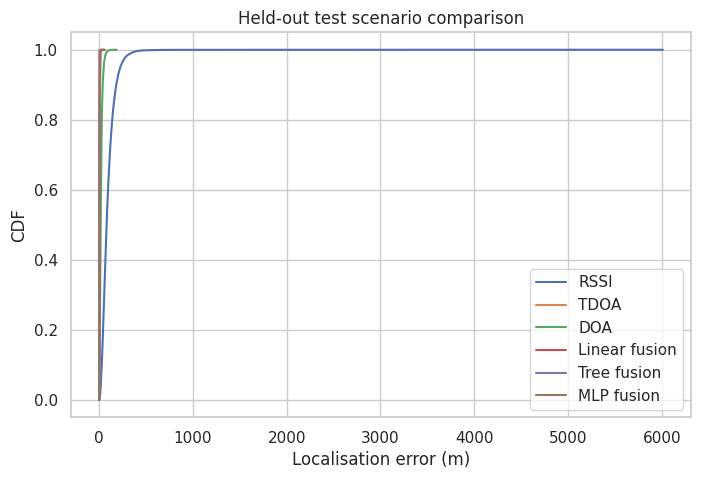

Tree fusion does not beat TDOA on this held-out test split. Report that honestly and inspect harder scenarios rather than deepening the network immediately.


In [14]:
final_prediction_map = {
    "RSSI": prediction_store["RSSI"],
    "TDOA": prediction_store["TDOA"],
    "DOA": prediction_store["DOA"],
    "Linear fusion": prediction_store["Linear fusion"],
    "Tree fusion": final_test_predictions,
    "MLP fusion": prediction_store["MLP fusion"],
}

final_test_summary_df = pd.DataFrame(
    [metric_row("test", model_name, y_test, preds) for model_name, preds in final_prediction_map.items()]
).sort_values("mean_error_m")
display(final_test_summary_df)

plt.figure(figsize=(8, 5))
for model_name, preds in final_prediction_map.items():
    errors = np.sort(localisation_error_m(y_test, preds))
    cdf = np.arange(1, len(errors) + 1) / len(errors)
    plt.plot(errors, cdf, label=model_name)

plt.xlabel("Localisation error (m)")
plt.ylabel("CDF")
plt.title("Held-out test scenario comparison")
plt.legend()
plt.show()

tree_mean = final_test_summary_df.loc[
    final_test_summary_df["model"] == "Tree fusion", "mean_error_m"
].iloc[0]
tdoa_mean = final_test_summary_df.loc[
    final_test_summary_df["model"] == "TDOA", "mean_error_m"
].iloc[0]

if tree_mean < tdoa_mean:
    print("Tree fusion beats TDOA on this held-out test split.")
else:
    print(
        "Tree fusion does not beat TDOA on this held-out test split. Report that honestly and inspect harder scenarios rather than deepening the network immediately."
    )


## 7. Optional: run the repo evaluator

If the repo is available in the Colab runtime, this step will run the existing evaluation script using the exported `ml_predictions.parquet` file.


In [16]:
EVALUATOR_SCRIPT = "/ML Pipeline/evaluate_positioning_performance.py"

if EVALUATOR_SCRIPT is None:
    print("Evaluator script not found in this runtime.")
    print("If needed, clone the repo in Colab or update EVALUATOR_SCRIPT manually.")
else:
    print(f"Running evaluator: {EVALUATOR_SCRIPT}")
    !python "{EVALUATOR_SCRIPT}" --data-dir "{DATA_DIR}" --predictions-path "{PREDICTIONS_PATH}"


Running evaluator: /ML Pipeline/evaluate_positioning_performance.py
Wrote positioning performance outputs:
- method_summary: /ML Pipeline/evaluation/method_performance_summary.csv
- condition_summary: /ML Pipeline/evaluation/condition_performance_summary.csv
- error_distribution: /ML Pipeline/evaluation/method_error_distribution.png
- error_cdf: /ML Pipeline/evaluation/method_error_cdf.png
- ml_improvement: /ML Pipeline/evaluation/ml_vs_baseline_improvement.csv
- paired_comparisons: /ML Pipeline/evaluation/paired_method_comparisons.csv
